In [1]:
import pandas as pd
import numpy as np
import sys
import gseapy as gp
from typing import Dict, Optional, Tuple, Any, List
import math
import json
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
from scipy.stats import spearmanr
import seaborn as sns

sys.path.append("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/")
from SynOmics.processing.metadata import MetaData
dataset_dict = {}
original_data = pd.read_csv("Data/original_data.csv", index_col = 0)
dataset_dict["Origin"] = original_data
seed = 42
syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
for i, tool in enumerate(syn_datas):
    syn_df = pd.read_csv(f"Data/{syn_datas[i]}.csv", index_col = 0)
    dataset_dict[tool] = syn_df


mapped_dataset = {}
with open("ssGSEA/mapping_genes.json", "r") as f:
    genes_mapping = json.load(f)
    
abnormal_counts = []
nan_counts = []
for k, v in genes_mapping.items():
    if isinstance(v[0], float) and math.isnan(v[0]):
        nan_counts.append([k, v])
        abnormal_counts.append([k,v])
    elif len(v) > 1 and isinstance(v[0], str):
        abnormal_counts.append([k,v])
        genes_mapping[k]=[v[0]]
            
def ensembl_to_hugo(col, mapping):
    ensembl_id = col.split('.')[0]  # Remove version
    hugo = mapping.get(ensembl_id, [col])  # fallback: leave as is if not found
    return str(hugo[0])
    

for k in nan_counts:
    genes_mapping.pop(k[0], None)

genes_cols = []
for col in original_data.columns:
    if col.startswith("ENSG"):
        genes_cols.append(col)
        
symbols_dataset_dict = {}
for tool, data in dataset_dict.items():
    genes_exp_df = data[genes_cols]
    # Rename column
    genes_exp_df_mapped = genes_exp_df.copy()
    genes_exp_df_mapped.columns = [ensembl_to_hugo(col, genes_mapping) for col in genes_exp_df_mapped.columns]
    
    drop_cols = [col for col in genes_exp_df_mapped.columns if col.startswith("ENSG")]
    genes_exp_df_mapped = genes_exp_df_mapped.drop(columns = drop_cols)
    
    genes_exp_df_mapped_t =genes_exp_df_mapped.T.reset_index()
    genes_exp_df_mapped_t.columns.values[0] = 'Gene'
    
    #Avaraging duplicated genes
    genes_exp_df_mapped_t_grouped = genes_exp_df_mapped_t.groupby("Gene", as_index=False).mean()
    symbols_dataset_dict[tool] = genes_exp_df_mapped_t_grouped

In [2]:
ssGSEA = {}
for k, df in symbols_dataset_dict.items():
    ss = gp.ssgsea(data=df,
                   gene_sets='MSigDB_Hallmark_2020',
                   sample_norm_method='rank', # choose 'custom' will only use the raw value of `data`
                   no_plot=False)
    ssGSEA[k] = ss.res2d

2025-12-07 17:47:29,738 [WARNING] Input gene rankings contains inf values!


In [3]:

terms = ssGSEA["Origin"]["Term"].unique()
phenotype = {"PBRM1": ["MUT","WT"]}
ph_col, ph_vals = next(iter(phenotype.items()))
phenotype_A = ph_vals[0]
phenotype_B = ph_vals[1]
ssGSEA_comparison = {}
data_names = list(dataset_dict.keys())

for data_name, df in dataset_dict.items():
    
    mut_patients = df[df[ph_col] == phenotype_A].index.tolist()
    wt_patients = df[df[ph_col] == phenotype_B].index.tolist()

    if len(mut_patients) == 0 or len(wt_patients) == 0:
        print(f"Warning: dataset '{data_name}' has empty group(s): "
              f"MUT={len(mut_patients)}, WT={len(wt_patients)}. "
              "All p-values and Diff_NES for this dataset will be NaN where groups are empty.")

    p_values = []
    scores = [] 

    
    ssGSEA_df = ssGSEA[data_name]
    for term in terms:
        if len(mut_patients) == 0 or len(wt_patients) == 0:
            p_values.append(np.nan)
            scores.append(np.nan) 
            continue

        df_term = ssGSEA_df[ssGSEA_df["Term"] == term]
        mut_term_df = df_term[df_term["Name"].isin(mut_patients)]
        wt_term_df = df_term[df_term["Name"].isin(wt_patients)]
        mut_term_score = mut_term_df["NES"].values.tolist()
        wt_term_score = wt_term_df["NES"].values.tolist()

        if len(mut_term_score) == 0 or len(wt_term_score) == 0:
            p_values.append(np.nan)
            scores.append(np.nan) 
            continue


        stat, p_value = mannwhitneyu(mut_term_score, wt_term_score, alternative='two-sided')
        p_values.append(float(p_value))
        
        #  Diff_NES (Mean NES_MUT - Mean NES_WT)
        score = np.mean(mut_term_score) - np.mean(wt_term_score)
        scores.append(score)

    p_values_arr = np.asarray(p_values, dtype=float)
    scores_arr = np.asarray(scores, dtype=float)
    
    valid_mask = ~np.isnan(p_values_arr)
    
    
    if valid_mask.sum() > 0:
        rejected, adj_pvals_valid, _, _ = multipletests(p_values_arr[valid_mask], alpha=0.05, method='fdr_bh')
        
        adj_pvals = np.full_like(p_values_arr, np.nan, dtype=float)
        adj_pvals[valid_mask] = adj_pvals_valid
    else:
        adj_pvals = np.full_like(p_values_arr, np.nan, dtype=float)
    rank_scores = scores_arr*(-np.log10(adj_pvals))
    ssresult_dict = {
        "Term": list(terms),
        "p_values": p_values_arr.tolist(),
        "adj_pvalues": adj_pvals.tolist(),
        "Diff_NES": scores_arr.tolist(),
        "Rank_Score": rank_scores.tolist()
    }
    ssGSEA_comparison[data_name] = pd.DataFrame(ssresult_dict)

ssGSEA_list = []
for name, df in ssGSEA_comparison.items():
    df["Dataset"] = [name]*(df.shape[0])
    ssGSEA_list.append(df)
ssGSEAall_df = pd.concat(ssGSEA_list, axis = 0)
# ssGSEAall_df.to_csv(f"ssGSEA/ssGSEA_comparison_PBRM1_{seed}.csv", index = False)

In [168]:
# -*- coding: utf-8 -*-
"""
plot_pathway_scatter.py

Provides a function to draw a grid of "volcano-style" pathway scatter plots from
ssGSEA results (adj. p-values, NES differences). Each subplot shows pathways
with adj_pvalue < threshold; x = Diff_NES (e.g. MUT - WT), size/color = -log10(adj_pvalue).

The function is adapted from an existing script and preserves the original
sorting/highlighting/visual conventions.

Example
-------
fig, summary = plot_pathway_scatter(ssGSEA_pvalues_dict)
fig.savefig("pathways.png", dpi=300)
"""



def plot_pathway_scatter(
    ssGSEA_pvalues_dict: Dict[str, pd.DataFrame],
    adj_p_threshold: float = 0.25,
    highlight_pathways: Optional[List[str]] = None,
    size_scale_factor: float = 150.0,
    ncols: int = 4,
    cmap = plt.cm.plasma_r,
    figsize: Optional[Tuple[float, float]] = None,
    show: bool = True,
    save_path: Optional[str] = None,
) -> Tuple[plt.Figure, Dict[str, pd.DataFrame]]:
    """
    Draw a grid of pathway scatter plots (one subplot per dataset) from ssGSEA results.

    Each dataset in `ssGSEA_pvalues_dict` must be a pandas.DataFrame containing at least:
        - 'Term' (pathway name)
        - 'adj_pvalues' (adjusted p-value / q-value)
        - 'Diff_NES' (difference in NES, e.g. MUT - WT)

    Args:
        ssGSEA_pvalues_dict (dict): Mapping dataset name -> pandas.DataFrame with ssGSEA
            results (columns as above).
        adj_p_threshold (float): Adjusted p-value threshold to keep pathways for plotting.
        highlight_pathways (list of str or None): Pathways to highlight (colored red).
        size_scale_factor (float): Scale factor for bubble sizes (multiplies -log10(qvalue)).
        ncols (int): Number of columns in the output grid.
        cmap (matplotlib colormap or None): Colormap used for bubbles. Defaults to plt.cm.plasma_r.
        figsize (tuple or None): Figure size (width, height). If None, automatically computed
            based on ncols and maximum number of pathways in a subplot.
        show (bool): If True, calls plt.show() after drawing.
        save_path (str or None): If provided, saves the figure to this path (dpi=300,
            bbox_inches='tight').

    Returns:
        tuple:
            - matplotlib.figure.Figure: The created figure object.
            - dict: Mapping dataset name -> DataFrame actually plotted (filtered by adj_p_threshold).
                Empty DataFrames are included for datasets without significant pathways.

    Raises:
        ValueError: If ssGSEA_pvalues_dict is empty.
    """
    if not ssGSEA_pvalues_dict:
        raise ValueError("ssGSEA_pvalues_dict must not be empty.")

    if cmap is None:
        cmap = plt.cm.plasma_r

    if highlight_pathways is None:
        highlight_pathways = []

    # Prepare data: keep only pathways passing the threshold per dataset and compute -log10(q)
    datasets = list(ssGSEA_pvalues_dict.keys())
    all_data_to_plot: Dict[str, pd.DataFrame] = {}
    global_nes_values = []
    global_pvalue_log = []
    max_pathways_in_one_plot = 0

    for ds_name in datasets:
        if ds_name not in ssGSEA_pvalues_dict:
            all_data_to_plot[ds_name] = pd.DataFrame()
            continue

        df_ds = ssGSEA_pvalues_dict[ds_name].copy()
        # require columns exist
        if "adj_pvalues" not in df_ds.columns or "Term" not in df_ds.columns or "Diff_NES" not in df_ds.columns:
            # store empty df for consistency
            all_data_to_plot[ds_name] = pd.DataFrame()
            continue

        sub_df = df_ds[df_ds["adj_pvalues"] < adj_p_threshold].copy()

        if not sub_df.empty:
            # compute -log10(qvalue), avoid log(0)
            sub_df["-log10(qvalue)"] = -np.log10(sub_df["adj_pvalues"].clip(lower=np.nextafter(0, 1)))
            # use Diff_NES (fillna -> 0)
            sub_df["NES_diff"] = sub_df["Diff_NES"].fillna(0)

            global_nes_values.extend(sub_df["NES_diff"].tolist())
            global_pvalue_log.extend(sub_df["-log10(qvalue)"].tolist())
            max_pathways_in_one_plot = max(max_pathways_in_one_plot, len(sub_df))

        all_data_to_plot[ds_name] = sub_df

    # If nothing to plot, return a small figure and message
    if max_pathways_in_one_plot == 0:
        fig = plt.figure(figsize=(6, 3))
        ax = fig.add_subplot(111)
        ax.text(
            0.5,
            0.5,
            f"No significant pathways (adj_p < {adj_p_threshold})",
            ha="center",
            va="center",
            fontsize=12,
            color="gray",
        )
        ax.axis("off")
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        if show:
            plt.show()
        return fig, all_data_to_plot

    # Global normalization scales
    max_abs_nes = np.nanmax(np.abs(global_nes_values))
    if max_abs_nes == 0 or np.isnan(max_abs_nes):
        max_abs_nes = 1.0

    norm_color_min = -np.log10(adj_p_threshold)
    norm_color_max = np.nanmax(global_pvalue_log)
    if np.isnan(norm_color_max) or norm_color_max < norm_color_min + 0.1:
        norm_color_max = norm_color_min + 1.0
    norm_color = Normalize(vmin=norm_color_min, vmax=norm_color_max)

    # Grid layout
    n_ds = len(datasets)
    nrows = int(math.ceil(n_ds / float(ncols)))
    n_plots_total = nrows * ncols

    # Default automatic figsize if not provided
    if figsize is None:
        width = 5.5 * ncols + 1
        height = max(0.4 * max_pathways_in_one_plot + 2, 7) * nrows
        figsize = (width, height)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharey=False, sharex=True)
    # ensure flattenable
    axes_flat = np.array(axes).flatten()

    color_A = "#e40c69"  # positive NES_diff (A)
    color_B = "#2e3092"  # negative NES_diff (B) -- note we color by pvalue, colors above are legacy

    # Plot each dataset
    for i, ds in enumerate(datasets):
        ax = axes_flat[i]
        sub_df = all_data_to_plot.get(ds)

        if sub_df is None or sub_df.empty:
            ax.text(
                0.5,
                0.5,
                "No significant pathways\n(p < " f"{adj_p_threshold})",
                ha="center",
                va="center",
                fontsize=10,
                color="grey",
                transform=ax.transAxes,
            )
            ax.set_title(ds, fontsize=12, fontweight="bold", pad=10)
            ax.axis("off")
            continue

        # sort by adj_pvalues ascending (most significant first)
        sub_df_sorted = sub_df.sort_values(by="adj_pvalues", ascending=True)

        pathways_this_plot = sub_df_sorted["Term"].tolist()
        y_labels = pathways_this_plot[::-1]  # reverse so most significant on top
        y_pos = np.arange(len(y_labels))

        mapping = {p: idx for idx, p in enumerate(y_labels)}
        y_values = sub_df_sorted["Term"].map(mapping)

        scatter_size = sub_df_sorted["-log10(qvalue)"] * size_scale_factor
        colors = sub_df_sorted["-log10(qvalue)"]
        x_values = sub_df_sorted["NES_diff"]

        # Scatter
        ax.scatter(
            x=x_values,
            y=y_values,
            s=scatter_size,
            c=colors,
            cmap=cmap,
            norm=norm_color,
            edgecolor="k",
            linewidths=0.4,
            alpha=0.9,
        )

        ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.5, zorder=-1)

        ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
        ax.set_xlabel("Diff_NES (MUT - WT)", fontsize=9, labelpad=5)

        # Y axis labels
        ax.set_yticks(y_pos)
        ax.set_yticklabels(y_labels, fontsize=9)
        # expand limits a little to avoid clipping bubbles
        ax.set_ylim(len(y_labels) - 0.5 + 1.5, -1.5)
        ax.invert_yaxis()

        ax.set_title(ds, fontsize=12, fontweight="bold", pad=10)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        # Highlight specific pathways
        for label in ax.get_yticklabels():
            pathway_name = label.get_text()
            if pathway_name in highlight_pathways:
                label.set_color("red")
                label.set_fontweight("bold")
            else:
                label.set_color("black")

    # Remove unused axes
    for j in range(n_ds, n_plots_total):
        fig.delaxes(axes_flat[j])

    # Colorbar on the right
    # place colorbar relative to figure
    fig.subplots_adjust(right=0.90)
    cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_color)
    cbar = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cbar.set_label("$-\\log_{10}(adj\\_pvalue)$", fontsize=10, labelpad=10)
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout(rect=[0, 0.03, 0.90, 0.98])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, all_data_to_plot

/tmp/ipykernel_1618103/3504592515.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 0.90, 0.98])


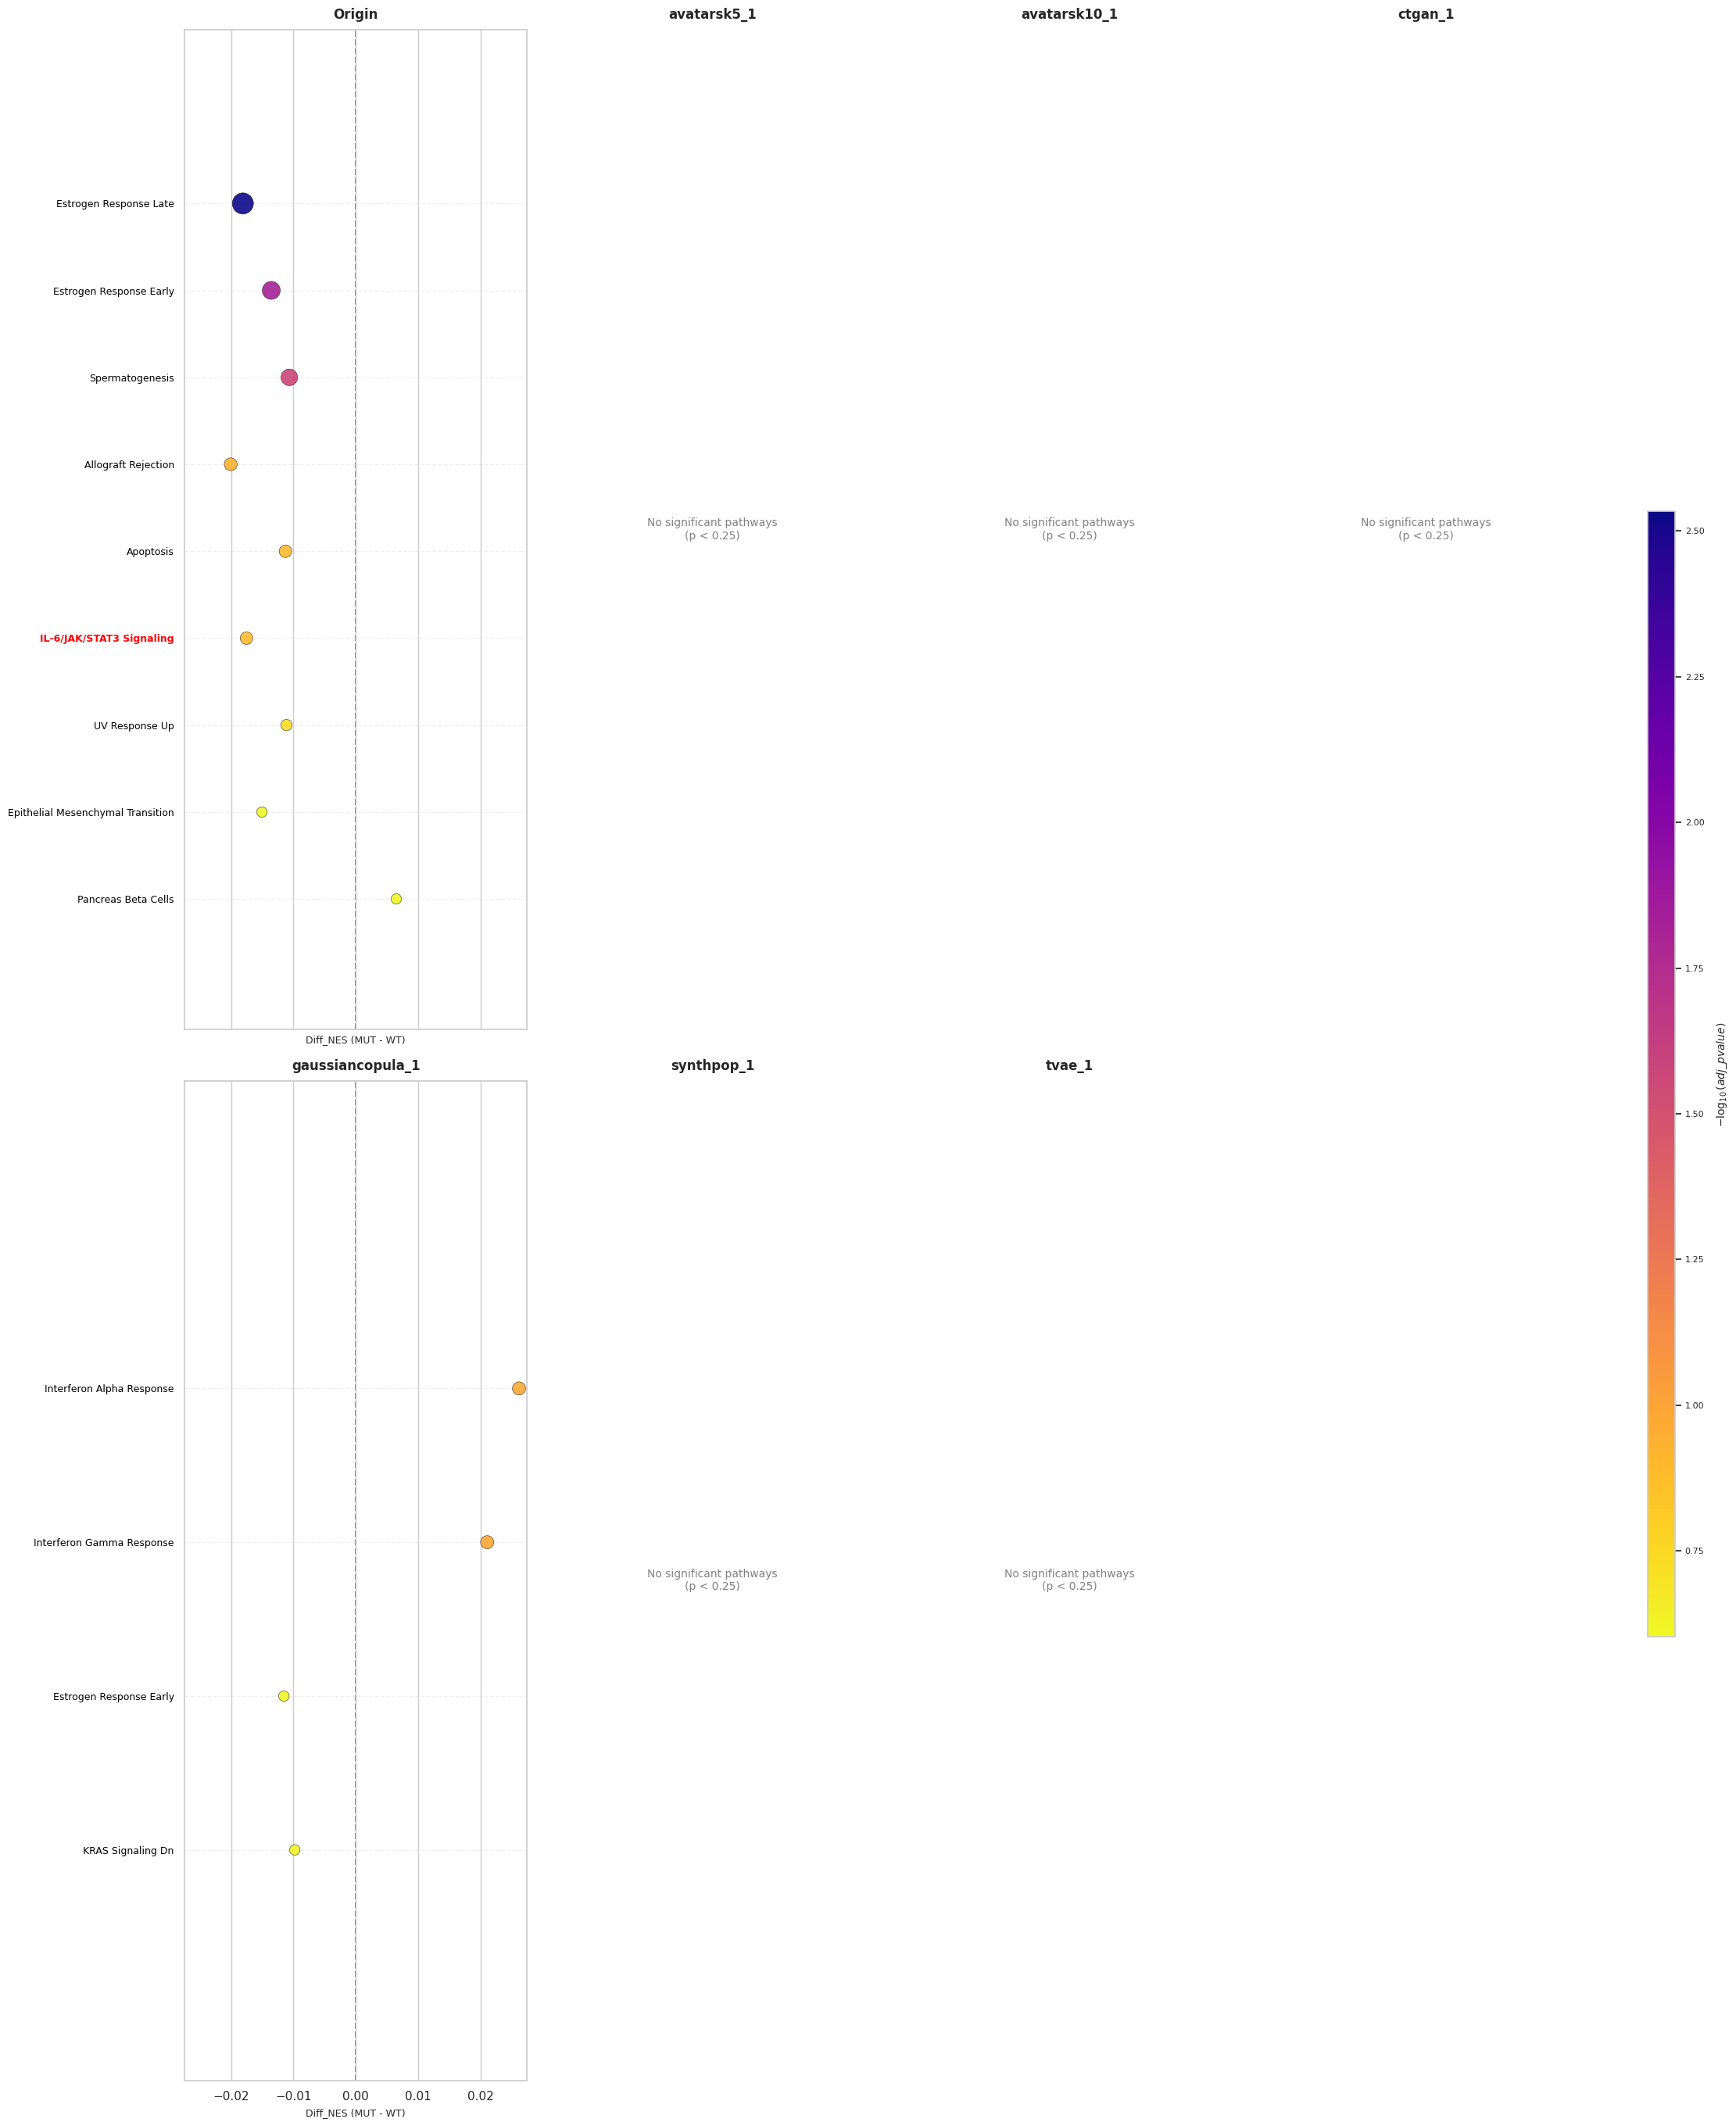

In [169]:
highlight_pathways = [
    'IL-6/JAK/STAT3 Signaling'
]
fig, plotted_dfs = plot_pathway_scatter(ssGSEA_comparison, ncols=ncols, highlight_pathways = highlight_pathways,
                                        figsize=(23.0, 28.8), save_path=f"ssGSEA/topsignificantpathways_{seed}.png")

topsignificants = []
for k, df in plotted_dfs.items():
    df["Dataset"] = [k]*df.shape[0]
    topsignificants.append(df)
topsignificant_df = pd.concat(topsignificants, axis = 0)
topsignificant_df.to_csv(f"ssGSEA/topsignificantpathways_{seed}.csv", index = False)

In [6]:
from collections import Iterable
def _to_set(pathways: Iterable[Any], case_sensitive: bool = False) -> set:
    if pathways is None:
        return set()
    if not case_sensitive:
        return {str(x).strip().lower() for x in pathways if pd.notna(x)}
    else:
        return {str(x).strip() for x in pathways if pd.notna(x)}


def compute_jaccard_indices(
    original_pathways: Iterable[Any],
    synth_pathways_dict: Dict[str, Iterable[Any]],
    case_sensitive: bool = False,
) -> pd.DataFrame:
    """
    The Jaccard index is defined as:
        J(A, B) = |A ∩ B| / |A ∪ B|
    """
    if not isinstance(synth_pathways_dict, dict):
        raise ValueError("synth_pathways_dict must be a dict mapping dataset name -> iterable of pathways")

    A = _to_set(original_pathways, case_sensitive=case_sensitive)
    rows = []
    for ds_name, synth_paths in synth_pathways_dict.items():
        B = _to_set(synth_paths, case_sensitive=case_sensitive)
        inter = A.intersection(B)
        union = A.union(B)
        inter_size = len(inter)
        union_size = len(union)

        if union_size == 0:
            # both sets empty -> identical
            j = 1.0
        else:
            j = inter_size / union_size

        rows.append(
            {
                "Dataset": ds_name,
                "Original_count": len(A),
                "Synthetic_count": len(B),
                "Intersection": inter_size,
                "Union": union_size,
                "Jaccard": j,
            }
        )

    df = pd.DataFrame(rows, columns=["Dataset", "Original_count", "Synthetic_count", "Intersection", "Union", "Jaccard"])
    return df


def extract_significant_pathways(
    df: pd.DataFrame,
    term_col: str = "Term",
    adj_p_col: str = "adj_pvalues",
    threshold: float = 0.25,
) -> List[str]:
    if df is None or df.empty:
        return []
    if term_col not in df.columns or adj_p_col not in df.columns:
        return []
    sub = df[df[adj_p_col].astype(float) < float(threshold)].copy()
    # drop NA/empty terms and return list
    sub = sub[sub[term_col].notna()]
    return [str(x).strip() for x in sub[term_col].tolist()]

/tmp/ipykernel_510393/2073597539.py:1: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated since Python 3.3, and in 3.10 it will stop working
  from collections import Iterable


In [25]:
orig_paths = extract_significant_pathways(ssGSEA_comparison["Origin"], term_col="Term", adj_p_col="adj_pvalues", threshold=0.25)
synth_paths_dict = {k: extract_significant_pathways(v, term_col="Term", adj_p_col="adj_pvalues", threshold=0.25)
                     for k, v in ssGSEA_comparison.items() if k != "Origin"}
jaccard_df = compute_jaccard_indices(orig_paths, synth_paths_dict)
jaccard_df
# jaccard_df.to_csv(f"ssGSEA/JaccardIndex_{seed}.csv", index = False)

,Dataset,Original_count,Synthetic_count,Intersection,Union,Jaccard
0,avatarsk5_42,9,11,2,18,0.111111
1,avatarsk10_42,9,26,6,29,0.206897
2,ctgan_42,9,1,0,10,0.000000
3,gaussiancopula_42,9,3,1,11,0.090909
4,synthpop_42,9,31,3,37,0.081081
5,tvae_42,9,0,0,9,0.000000


In [26]:
pivot_df = ssGSEAall_df.pivot_table(
    index="Term",
    columns="Dataset",
    values="Rank_Score"
)
if "tvae_42" not in pivot_df.columns.tolist():
    pivot_df["tvae_42"] = np.nan

origin_values = pivot_df["Origin"]

results = []

for dataset in pivot_df.columns:
    if dataset == "Origin":
        continue  # skip comparison with itself
    
    x = origin_values
    y = pivot_df[dataset]

    # Drop rows where either side is NaN
    valid = ~(x.isna() | y.isna())
    rho, pval = spearmanr(x[valid], y[valid])

    results.append({
        "Dataset": dataset,
        "Spearman_rho": rho,
        "p_value": pval,
        "n_terms_used": valid.sum()
    })

# Convert results to DataFrame
spearman_df = pd.DataFrame(results)
spearman_df
# spearman_df.to_csv(f"ssGSEA/Spearman_df{seed}.csv", index = False)

,Dataset,Spearman_rho,p_value,n_terms_used
0,avatarsk10_42,0.679328,5.835517e-08,50
1,avatarsk5_42,0.590588,6.339207e-06,50
2,ctgan_42,0.189148,1.883221e-01,50
3,gaussiancopula_42,0.748379,4.164079e-10,50
4,synthpop_42,0.091381,5.279506e-01,50
5,tvae_42,NaN,NaN,0


In [12]:
# -*- coding: utf-8 -*-
"""
Create a scatter plot visualizing Jaccard index vs Spearman rho for synthetic datasets
compared to an Original dataset.

Args:
    jaccard_df (pd.DataFrame): DataFrame with Jaccard results. Must contain at least:
        'Dataset' and 'Jaccard'. Optional columns used: 'Synthetic_count', 'Original_count'.
    spearman_df (pd.DataFrame): DataFrame with Spearman results. Must contain at least:
        'Dataset' and 'Spearman_rho'. Optional columns used: 'n_terms_used', 'p_value'.
    dataset_col (str): Column name for dataset identifier (default 'Dataset').
    jaccard_col (str): Column name for Jaccard index in jaccard_df (default 'Jaccard').
    spearman_col (str): Column name for Spearman rho in spearman_df (default 'Spearman_rho').
    size_col (str or None): Column used for point sizes (e.g. 'Synthetic_count'); if None,
        sizes are uniform.
    annotate (bool): Whether to annotate points with dataset labels.
    figsize (tuple): Figure size (width, height).
    savepath (str or None): If given, saves the figure to this path.

Returns:
    matplotlib.figure.Figure, matplotlib.axes.Axes: The created figure and axes.

Raises:
    ValueError: If required columns are missing in the input DataFrames.
"""



def plot_jaccard_vs_spearman(
    jaccard_df: pd.DataFrame,
    spearman_df: pd.DataFrame,
    dataset_col: str = "Dataset",
    jaccard_col: str = "Jaccard",
    spearman_col: str = "Spearman_rho",
    size_col: Optional[str] = "Synthetic_count",
    annotate: bool = True,
    figsize: Tuple[float, float] = (8, 6),
    savepath: Optional[str] = None,
    title: Optional[str] = "Jaccard index vs Spearman rho",
) -> Tuple[plt.Figure, plt.Axes]:
    # Validate inputs
    if dataset_col not in jaccard_df.columns:
        raise ValueError(f"{dataset_col} not found in jaccard_df")
    if dataset_col not in spearman_df.columns:
        raise ValueError(f"{dataset_col} not found in spearman_df")
    if jaccard_col not in jaccard_df.columns:
        raise ValueError(f"{jaccard_col} not found in jaccard_df")
    if spearman_col not in spearman_df.columns:
        raise ValueError(f"{spearman_col} not found in spearman_df")

    # Merge on dataset
    df = pd.merge(
        spearman_df,
        jaccard_df,
        on=dataset_col,
        how="outer",
        suffixes=("_spearman", "_jaccard"),
    )

    # Prepare columns
    df = df.rename(columns={jaccard_col: "Jaccard", spearman_col: "Spearman_rho"})
    # If user requested size_col but it has different name in jaccard_df, try to keep as-is
    if size_col is not None and size_col not in df.columns:
        # fall back to n_terms_used or Synthetic_count if available
        if "n_terms_used" in df.columns:
            size_col = "n_terms_used"
        elif "Synthetic_count" in df.columns:
            size_col = "Synthetic_count"
        else:
            size_col = None

    # Drop rows that do not have both metrics (can't plot)
    plot_df = df.loc[df["Jaccard"].notna() & df["Spearman_rho"].notna()].copy()

    # If no rows to plot, create empty figure with message
    if plot_df.shape[0] == 0:
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, "No datasets with both Jaccard and Spearman available", ha="center", va="center")
        ax.axis("off")
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        return fig, ax

    # # Compute Spearman correlation between Jaccard and Spearman_rho (on available rows)
    # rho, pval = spearmanr(plot_df["Jaccard"], plot_df["Spearman_rho"], nan_policy="omit")

    # Determine point sizes
    if size_col is not None:
        # scale sizes to a reasonable range
        raw_sizes = plot_df[size_col].fillna(0).astype(float)
        # map zero -> small, others scaled
        min_size = 50
        max_size = 450
        if raw_sizes.max() == raw_sizes.min():
            sizes = np.full(len(raw_sizes), (min_size + max_size) / 2.0)
        else:
            sizes = min_size + (raw_sizes - raw_sizes.min()) / (raw_sizes.max() - raw_sizes.min()) * (max_size - min_size)
    else:
        sizes = 120

    # Create plot
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=figsize)

    scatter = ax.scatter(
        x=plot_df["Jaccard"],
        y=plot_df["Spearman_rho"],
        s=sizes,
        c="tab:blue",
        edgecolor="k",
        alpha=0.85,
        linewidth=0.6,
        zorder=3,
    )


    # Annotate each point with dataset name if requested (with small offset)
    if annotate:
        for _, row in plot_df.iterrows():
            dx = 0.005 * (ax.get_xlim()[1] - ax.get_xlim()[0])  # small fraction of x-range
            dy = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])  # small fraction of y-range
            ax.text(
                row["Jaccard"] + dx,
                row["Spearman_rho"] + dy,
                str(row[dataset_col]),
                fontsize=8,
                verticalalignment="bottom",
                horizontalalignment="left",
            )

    # Labels, title, legend, annotation for correlation
    ax.set_xlabel("Jaccard index", fontsize=11)
    ax.set_ylabel("Spearman rho", fontsize=11)
    ax.set_title(title, fontsize=12)



    # A grid and tight layout
    ax.grid(alpha=0.4, linestyle="--")
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, ax

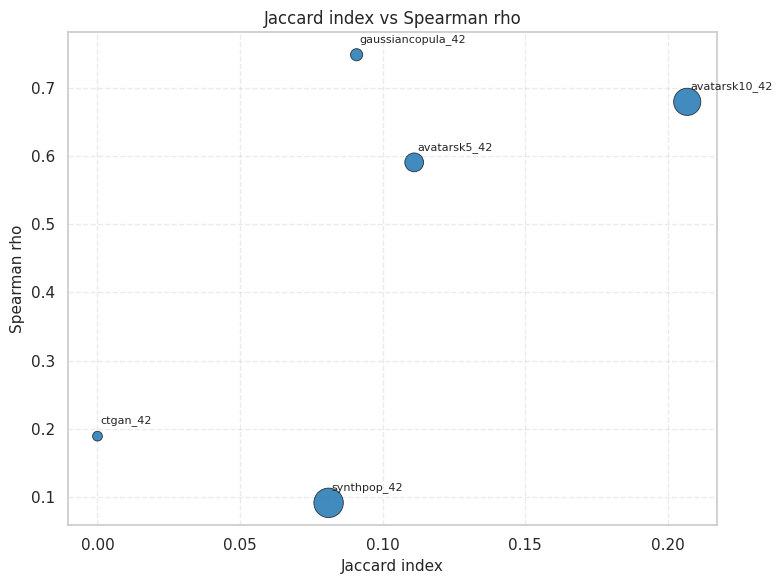

In [22]:
fig, ax = plot_jaccard_vs_spearman(jaccard_df, spearman_df, 
                                   size_col="Synthetic_count", annotate=True, savepath=None)
plt.show()

In [19]:
# -*- coding: utf-8 -*-
"""
Draw a fixed-list pathway scatter grid from ssGSEA comparison results, with:
- Unified x-axis range across panels
- Bubble color by p-value bin (not gradient)
- **Fixed bubble size** (bubble size does NOT encode p-value or any data variable)

Returns:
    tuple: (matplotlib.figure.Figure, pandas.DataFrame)
        - Figure: The created matplotlib Figure object.
        - DataFrame: The concatenated DataFrame used for plotting (columns include
          ['Dataset','Term','adj_pvalues','Diff_NES','-log10(qvalue)','NES_diff','y', 'pvalue_bin']).
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Any, Tuple
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_pathway_fixed_list(
    ssGSEA_comparison: Dict[str, pd.DataFrame],
    ref_pathway_list: List[str] = [
        'Estrogen Response Late', 'Estrogen Response Early', 'Spermatogenesis',
        'Allograft Rejection', 'IL-6/JAK/STAT3 Signaling','Apoptosis','UV Response Up',
        'Pancreas Beta Cells','Epithelial Mesenchymal Transition'
    ],
    highlight_pathways: List[str] = ['IL-6/JAK/STAT3 Signaling'],
    origin_name: str = "Origin",
    adj_p_threshold: float = 0.25,
    pval_bin_colors: List[str] = ["#d62728", "#ff7f0e", "#1f77b4", "#cccccc"],  # red, orange, blue, gray
    fig_width_min: float = 14.0,
    bubble_size: float = 170,   # Fixed size for all bubbles
    show: bool = True,
    save_path: Optional[str] = None,
    return_dataframe: bool = True,
) -> Tuple[plt.Figure, pd.DataFrame]:
    if not ssGSEA_comparison:
        raise ValueError("ssGSEA_comparison must not be empty.")
    if not ref_pathway_list:
        raise ValueError("ref_pathway_list must not be empty.")

    datasets = list(ssGSEA_comparison.keys())

    # Prepare filtered data and global scales
    all_data_to_plot = []
    global_nes_values = []

    for ds_name in datasets:
        if ds_name not in ssGSEA_comparison:
            continue
        df_ds = ssGSEA_comparison[ds_name].copy()

        if "Term" not in df_ds.columns or "adj_pvalues" not in df_ds.columns or "Diff_NES" not in df_ds.columns:
            continue

        sub_df = df_ds[df_ds["Term"].isin(ref_pathway_list)].copy()
        if sub_df.empty:
            continue

        sub_df["Dataset"] = ds_name
        sub_df["-log10(qvalue)"] = -np.log10(sub_df["adj_pvalues"].clip(lower=np.nextafter(0, 1)))
        sub_df["NES_diff"] = sub_df["Diff_NES"].fillna(0)

        global_nes_values.extend(sub_df["NES_diff"].tolist())
        all_data_to_plot.append(sub_df)

    if not all_data_to_plot:
        fig = plt.figure(figsize=(8, 3))
        ax = fig.add_subplot(111)
        ax.text(0.5, 0.5, "No data to plot for the provided reference pathways.", ha="center", va="center", fontsize=12)
        ax.axis("off")
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        if show:
            plt.show()
        return (fig, pd.DataFrame([])) if return_dataframe else (fig, None)

    df_plot = pd.concat(all_data_to_plot, ignore_index=True)

    # --- Unified axes: use global NES range across all datasets ---
    max_abs_nes = np.nanmax(np.abs(global_nes_values))
    if max_abs_nes == 0 or np.isnan(max_abs_nes):
        max_abs_nes = 1.0

    # --- p-value bins and colors ---
    bins = [0, 0.01, 0.05, 0.25, 1.01]
    bin_labels = ["p<0.01", "0.01≤p<0.05", "0.05≤p<0.25", "p≥0.25"]
    color_map = dict(zip(bin_labels, pval_bin_colors))
    df_plot["pvalue_bin"] = pd.cut(df_plot["adj_pvalues"], bins=bins, labels=bin_labels, include_lowest=True, right=False)

    # Y ordering
    origin_df = df_plot[df_plot["Dataset"] == origin_name].copy()
    if not origin_df.empty:
        origin_df = origin_df.sort_values(by="adj_pvalues", ascending=True)
        sorted_pathways = origin_df["Term"].tolist()
        for p in ref_pathway_list:
            if p not in sorted_pathways:
                sorted_pathways.append(p)
        sorted_pathways = [p for p in sorted_pathways if p in ref_pathway_list]
    else:
        sorted_pathways = [p for p in ref_pathway_list if p in df_plot["Term"].unique()]
        if not sorted_pathways:
            sorted_pathways = sorted(list(df_plot["Term"].unique()))
    y_labels = sorted_pathways[::-1]
    y_pos = np.arange(len(y_labels))
    mapping = {p: idx for idx, p in enumerate(y_labels)}

    N_COLS = len(datasets)
    FIG_WIDTH = max(3.5 * N_COLS + 2, fig_width_min)
    FIG_HEIGHT = max(0.6 * len(y_labels) + 3, 7)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=N_COLS,
        figsize=(FIG_WIDTH, FIG_HEIGHT),
        sharey=True,
        sharex=True,
    )

    if N_COLS == 1:
        axes_list = [axes]
    else:
        axes_list = list(np.array(axes).flatten())

    plt.subplots_adjust(left=0.25, right=0.90, top=0.85, bottom=0.08, wspace=0.15)

    for i, ds in enumerate(datasets):
        ax = axes_list[i]
        sub = df_plot[df_plot["Dataset"] == ds].copy()
        sub["y"] = sub["Term"].map(mapping)

        if sub.empty or sub["y"].isna().all():
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10, color="grey", transform=ax.transAxes)
            ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
            ax.set_xticks([])
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=10)
            ax.tick_params(left=False, labelleft=False)
            ax.grid(axis="y", linestyle="--", alpha=0.4)
            continue

        bubble_colors = sub["pvalue_bin"].map(color_map).fillna("#cccccc")

        ax.scatter(
            x=sub["NES_diff"],
            y=sub["y"],
            s=bubble_size,
            c=bubble_colors,
            edgecolor="k",
            linewidths=0.4,
            alpha=0.9,
        )

        ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.5, zorder=-1)
        ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
        ax.set_xlabel("NES_change (MUT - WT)", fontsize=9, labelpad=5)

        ax.set_yticks(y_pos)
        ax.set_ylim(len(y_labels) - 0.5 + 0.5, -0.5 - 0.5)
        ax.invert_yaxis()
        ax.set_title(ds, fontsize=10, fontweight="bold", pad=10)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

        if i == 0:
            ax.set_yticklabels(y_labels, fontsize=9)
            ax.tick_params(axis="y", which="major", pad=5)
            for label in ax.get_yticklabels():
                pathway_name = label.get_text()
                if pathway_name in highlight_pathways:
                    label.set_color("red")
                    label.set_fontweight("bold")
                else:
                    label.set_color("black")
        else:
            ax.tick_params(left=False, labelleft=False)

    # Remove unused axes
    if len(axes_list) > N_COLS:
        for j in range(N_COLS, len(axes_list)):
            fig.delaxes(axes_list[j])

    # Add manual legend for p-value bins
    import matplotlib.patches as mpatches
    legend_patches = [
        mpatches.Patch(color=color_map[l], label=l)
        for l in bin_labels
    ]
    axes_list[-1].legend(handles=legend_patches, title="Adjusted p-value", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title_fontsize=9, frameon=False)

    plt.tight_layout(rect=[0, 0.03, 0.90, 0.98])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    df_plot["y"] = df_plot["Term"].map(mapping)

    return (fig, df_plot) if return_dataframe else (fig, None)

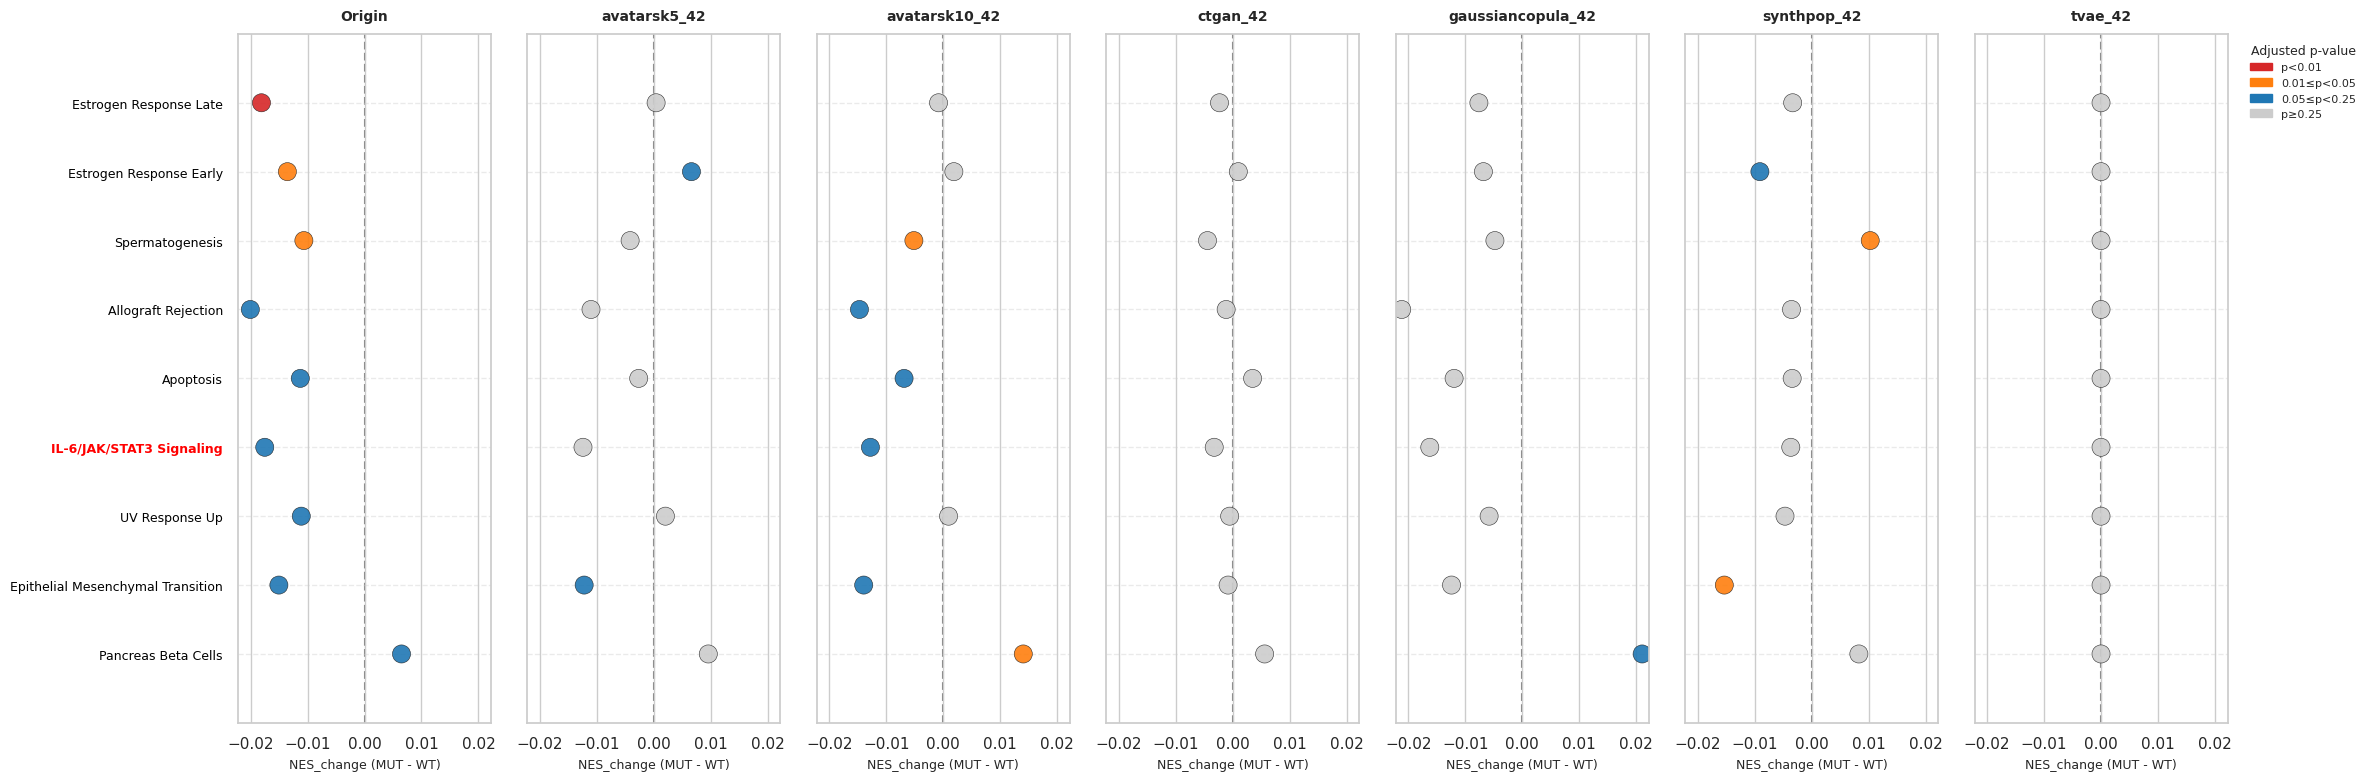

In [24]:
ref_pathway_list = ['Estrogen Response Late', 'Estrogen Response Early', 'Spermatogenesis',
 'Allograft Rejection', 'IL-6/JAK/STAT3 Signaling','Apoptosis','UV Response Up',
 'Pancreas Beta Cells','Epithelial Mesenchymal Transition']
highlight_pathways = ['IL-6/JAK/STAT3 Signaling']

# Call the plotting function
fig, df_used = plot_pathway_fixed_list(
    ssGSEA_comparison=ssGSEA_comparison,
    ref_pathway_list=ref_pathway_list,
    highlight_pathways=highlight_pathways,
    origin_name="Origin",
    adj_p_threshold=0.25,
    show=True,
    save_path=f'ssGSEA/BubblePlot_color_scaled_PBRM1.png'
)
# fig.savefig(f'ssGSEA/BubblePlot_color_scaled_PBRM1.png', dpi = 300)
plt.show()